<a href="https://colab.research.google.com/github/Himanshu0518/ADOBE_HACKATHON/blob/main/notebooks/fanp_RFM_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
order_df = pd.read_csv("/content/orders.csv")
order_df.head()

,Order_ID,Customer_ID,Product_ID,Quantity,Order_Date,Order_Time,Delivery_Date,Delivery_Time,Location,Occasion
0,1,C037,67,5,24-02-2023,23:48:13,05-03-2023,07:27:10,Bardhaman,Anniversary
1,2,C019,41,2,07-11-2023,23:30:18,13-11-2023,07:16:17,Jaipur,Diwali
2,3,C029,67,5,14-07-2023,19:12:03,19-07-2023,17:39:00,Bilaspur,Anniversary
3,4,C012,14,5,10-07-2023,04:44:29,19-07-2023,06:33:23,Guwahati,Birthday
4,5,C078,58,2,11-02-2023,19:44:48,18-02-2023,11:08:52,Rajkot,Valentine's Day


In [4]:
customer_df=pd.read_csv('/content/customers.csv')
customer_df.head()

,Customer_ID,Name,City,Contact_Number,Email,Gender,Address
0,C001,Tara Krishnan,Panchkula,917193971454,mandrati@chad.org,Female,"65/04\nDhawan Marg, Rajpur Sonarpur 590551"
1,C002,Myra Edwin,Bulandshahr,8915420519,yshukla@hotmail.com,Female,H.No. 78\nSharaf Ganj\nIndore 928261
2,C003,Jayesh Lanka,Bilaspur,7400208126,kavyabarad@hotmail.com,Male,"H.No. 53, Krishna Ganj, Dhule-346480"
3,C004,Tarini Bava,Miryalaguda,7232349928,vsen@hotmail.com,Male,"145\nSibal, Rourkela-650344"
4,C005,Hiran Kaul,Kottayam,2207644242,hanshkapur@buch.biz,Male,34/168\nSachar Street\nBhatpara 002691


In [5]:
products_df=pd.read_csv('/content/products.csv')
products_df.head()

,Product_ID,Product_Name,Category,Price (INR),Occasion,Description
0,1,Magnam Set,Soft Toys,1935,All Occasions,Quam numquam iste sunt nemo.
1,2,Voluptas Box,Plants,441,Valentine's Day,At quaerat animi nemo.
2,3,Eius Gift,Colors,1534,Valentine's Day,Deserunt pariatur mollitia voluptatem.
3,4,Accusantium Set,Sweets,1199,Diwali,Corporis odio consequatur perferendis repellen...
4,5,Natus Gift,Colors,1444,All Occasions,Quis occaecati reprehenderit facere tenetur il...


In [6]:
df = pd.merge(order_df, products_df, on='Product_ID', suffixes=('_order', '_product'))

df = df.drop(columns=['Occasion_product'])
df = df.rename(columns={'Occasion_order': 'Occasion'})

df['Revenue'] = df['Quantity'] * df['Price (INR)']

df.head()

,Order_ID,Customer_ID,Product_ID,Quantity,Order_Date,Order_Time,Delivery_Date,Delivery_Time,Location,Occasion,Product_Name,Category,Price (INR),Description,Revenue
0,1,C037,67,5,24-02-2023,23:48:13,05-03-2023,07:27:10,Bardhaman,Anniversary,Maiores Box,Raksha Bandhan,1374,Earum quos enim minima.,6870
1,2,C019,41,2,07-11-2023,23:30:18,13-11-2023,07:16:17,Jaipur,Diwali,Aut Box,Sweets,1977,Ab quisquam nobis ducimus.,3954
2,3,C029,67,5,14-07-2023,19:12:03,19-07-2023,17:39:00,Bilaspur,Anniversary,Maiores Box,Raksha Bandhan,1374,Earum quos enim minima.,6870
3,4,C012,14,5,10-07-2023,04:44:29,19-07-2023,06:33:23,Guwahati,Birthday,Deserunt Box,Colors,1915,Incidunt hic vero esse saepe illum.,9575
4,5,C078,58,2,11-02-2023,19:44:48,18-02-2023,11:08:52,Rajkot,Valentine's Day,Sed Pack,Cake,1492,Reiciendis nam omnis vel explicabo amet perfer...,2984


In [7]:
# Convert Order_Date to datetime objects
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')

### RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is a marketing technique used to quantitatively rank and group customers based on their transaction history. It's widely used in database marketing and direct marketing and has proven to be a reliable method for identifying a business's best customers.

Here's what each term means:

*   **Recency**: How recently did the customer make a purchase? Customers who have purchased recently are more likely to respond to promotions.
*   **Frequency**: How often do they purchase? Customers who purchase frequently are generally more engaged and loyal.
*   **Monetary**: How much money do they spend? Customers who spend more are often more valuable to the business.

#### 1. Calculate Recency

To calculate Recency, we need to find the latest purchase date for each customer and then determine how many days have passed since that last purchase. We will use the maximum `Order_Date` in the entire dataset as our reference point to ensure all recency scores are relative to the most recent transaction recorded.

In [8]:
# Calculate Recency

# Get the last order date in the entire dataset as the reference date
reference_date = df['Order_Date'].max()

# Group by Customer_ID and find the latest purchase date for each customer
recency_df = df.groupby('Customer_ID')['Order_Date'].max().reset_index()

# Calculate the number of days since the last purchase from the reference date
recency_df['Recency'] = (reference_date - recency_df['Order_Date']).dt.days

# Display the first few rows of the recency DataFrame
display(recency_df[['Customer_ID', 'Recency']].head())

,Customer_ID,Recency
0,C001,124
1,C002,53
2,C003,51
3,C004,4
4,C005,122


#### 2. Calculate Frequency

Frequency measures how often a customer makes a purchase. A higher frequency score indicates a more engaged and loyal customer. To calculate this, we will count the number of unique `Order_ID`s for each `Customer_ID`.

In [9]:
# Calculate Frequency

# Group by Customer_ID and count the number of unique orders
frequency_df = df.groupby('Customer_ID')['Order_ID'].nunique().reset_index()

# Rename the column to 'Frequency'
frequency_df.rename(columns={'Order_ID': 'Frequency'}, inplace=True)

# Display the first few rows of the frequency DataFrame
display(frequency_df.head())

,Customer_ID,Frequency
0,C001,5
1,C002,8
2,C003,10
3,C004,11
4,C005,4


#### 3. Calculate Monetary

Monetary value represents the total amount of money a customer has spent. Customers who spend more are generally considered more valuable. To calculate this, we will sum the `Revenue` for each `Customer_ID`.

In [10]:
# Calculate Monetary

# Group by Customer_ID and sum the 'Revenue' for each customer
monetary_df = df.groupby('Customer_ID')['Revenue'].sum().reset_index()

# Rename the column to 'Monetary'
monetary_df.rename(columns={'Revenue': 'Monetary'}, inplace=True)

# Display the first few rows of the monetary DataFrame
display(monetary_df.head())

,Customer_ID,Monetary
0,C001,9095
1,C002,23860
2,C003,34871
3,C004,35894
4,C005,8403


#### 4. Combine R, F, and M into one DataFrame

Now that we have calculated the individual Recency, Frequency, and Monetary scores, we need to combine them into a single DataFrame. This consolidated DataFrame will be used to assign RFM scores and segment customers.

In [11]:
# Merge the three dataframes (Recency, Frequency, Monetary)
rfm_df = recency_df.merge(frequency_df, on='Customer_ID')
rfm_df = rfm_df.merge(monetary_df, on='Customer_ID')

# Drop the 'Order_Date' column as it's no longer needed in the RFM dataframe
rfm_df.drop('Order_Date', axis=1, inplace=True)

# Display the first few rows of the combined RFM DataFrame
display(rfm_df.head())

,Customer_ID,Recency,Frequency,Monetary
0,C001,124,5,9095
1,C002,53,8,23860
2,C003,51,10,34871
3,C004,4,11,35894
4,C005,122,4,8403


#### 5. Assign RFM Scores

To effectively segment customers, we need to assign scores to their Recency, Frequency, and Monetary values. A common approach is to divide customers into a certain number of quantiles (e.g., 5 quantiles, resulting in scores from 1 to 5) for each metric.

*   For **Recency**, a lower value is better (more recent purchase), so we will assign higher scores to lower recency values.
*   For **Frequency** and **Monetary**, higher values are better, so we will assign higher scores to higher frequency and monetary values.

In [12]:
# Assign scores for Recency, Frequency, and Monetary
# For Recency, lower values get higher scores (qcut creates bins, we reverse the scores)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=[5, 4, 3, 2, 1])

# For Frequency and Monetary, higher values get higher scores
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'], 5, labels=[1, 2, 3, 4, 5])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Display the RFM DataFrame with the new scores
display(rfm_df.head())

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,C001,124,5,9095,1,1,1
1,C002,53,8,23860,2,1,1
2,C003,51,10,34871,2,3,3
3,C004,4,11,35894,5,3,3
4,C005,122,4,8403,1,1,1


#### 6. Create RFM Segments

After assigning individual R, F, and M scores, we can combine them to create an RFM Segment string (e.g., '555' for the best customers) or a combined RFM Score. These segments will allow us to classify customers into meaningful groups.

In [13]:
# Concatenate R, F, and M scores to create RFM Segment
rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

# Also, create a combined RFM Score by summing R, F, and M scores (useful for overall ranking)
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(int) + rfm_df['F_Score'].astype(int) + rfm_df['M_Score'].astype(int)

# Display the RFM DataFrame with the new RFM Segment and RFM Score
display(rfm_df.head())

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,C001,124,5,9095,1,1,1,111,3
1,C002,53,8,23860,2,1,1,211,4
2,C003,51,10,34871,2,3,3,233,8
3,C004,4,11,35894,5,3,3,533,11
4,C005,122,4,8403,1,1,1,111,3


#### 7. Define RFM Customer Segments

With the RFM scores and segments calculated, we can now define meaningful customer segments. This involves grouping customers based on their combined RFM scores or segments to identify different customer behaviors and characteristics. For example, customers with high R, F, and M scores (e.g., 555) are typically 'Best Customers', while those with low scores might be 'Lost Customers'.

In [14]:
# Define a function to assign customer segments based on RFM scores
def rfm_segment(df):
    if df['RFM_Score'] >= 13:
        return 'Champions'
    elif (df['RFM_Score'] >= 10) and (df['RFM_Score'] < 13):
        return 'Loyal Customers'
    elif (df['RFM_Score'] >= 7) and (df['RFM_Score'] < 10):
        return 'Potential Loyalist'
    elif (df['RFM_Score'] >= 4) and (df['RFM_Score'] < 7):
        return 'At Risk Customers'
    else:
        return 'Lost Customers'

# Apply the function to create a new 'Segment' column
rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)

# Display the count of customers in each segment
display(rfm_df['Segment'].value_counts().reset_index())

# Display the RFM DataFrame with the new Segment column
display(rfm_df.head())

,Segment,count
0,Potential Loyalist,32
1,Loyal Customers,31
2,At Risk Customers,22
3,Champions,12
4,Lost Customers,3


,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment
0,C001,124,5,9095,1,1,1,111,3,Lost Customers
1,C002,53,8,23860,2,1,1,211,4,At Risk Customers
2,C003,51,10,34871,2,3,3,233,8,Potential Loyalist
3,C004,4,11,35894,5,3,3,533,11,Loyal Customers
4,C005,122,4,8403,1,1,1,111,3,Lost Customers


#### 8. Analyze RFM Segments

Now that we have segmented our customers, let's analyze the characteristics of each segment. This involves calculating the average Recency, Frequency, and Monetary values for each segment to understand their behavior patterns.

In [15]:
# Calculate the mean R, F, and M for each segment
segment_analysis = rfm_df.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

# Sort the segments for better readability, e.g., by RFM score or segment name
segment_analysis.sort_values(by='Recency', ascending=True, inplace=True)

# Display the segment analysis
display(segment_analysis)

,Segment,Recency,Frequency,Monetary
1,Champions,13.250000,14.166667,51950.916667
3,Loyal Customers,34.806452,11.322581,40662.935484
4,Potential Loyalist,45.781250,9.406250,32417.968750
0,At Risk Customers,77.272727,7.318182,25328.090909
2,Lost Customers,124.333333,5.666667,14143.000000


#### 9. Visualize RFM Segments

Visualizing the average Recency, Frequency, and Monetary values for each segment can provide a clearer picture of their distinct characteristics. This helps in quickly grasping the differences between customer groups and formulating targeted marketing strategies.

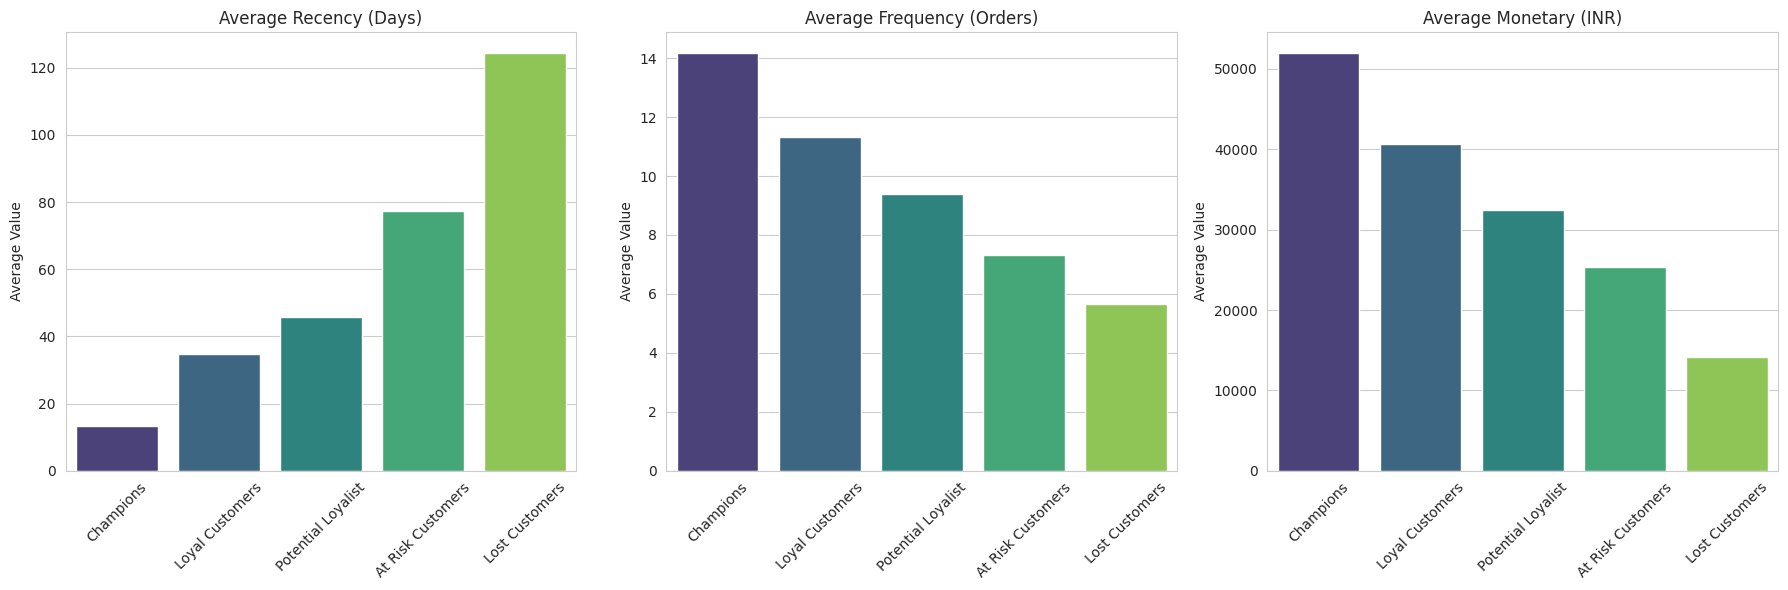

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style('whitegrid')

# Prepare data for plotting
segment_analysis_melted = segment_analysis.melt(id_vars=['Segment'],
                                              value_vars=['Recency', 'Frequency', 'Monetary'],
                                              var_name='Metric',
                                              value_name='Average Value')

# Create subplots for each RFM metric
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

metrics = ['Recency', 'Frequency', 'Monetary']
titles = ['Average Recency (Days)', 'Average Frequency (Orders)', 'Average Monetary (INR)']

for i, metric in enumerate(metrics):
    sns.barplot(x='Segment',
                y='Average Value',
                data=segment_analysis_melted[segment_analysis_melted['Metric'] == metric],
                ax=axes[i],
                palette='viridis',
                hue='Segment', # Add hue to suppress FutureWarnings
                legend=False) # Set legend to False as hue is x
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Average Value')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

These plots visually confirm the distinctions between our customer segments. For example, 'Champions' show the lowest average Recency (meaning they purchased most recently) and the highest average Frequency and Monetary values, while 'Lost Customers' exhibit the opposite trends. This visualization makes it easy to understand the relative value and engagement of each customer group.